In [1]:
import torch 
import numpy as np 
import matplotlib.pyplot as plt
from itertools import islice
import json
from tqdm.auto import tqdm

from cryo_sbi.wpa_simulator.cryo_em_simulator import cryo_em_simulator
from cryo_sbi import CryoEmSimulator
from cryo_sbi.inference.models import build_models
import cryo_sbi.utils.estimator_utils as est_utils
from cryo_sbi.inference.priors import get_image_priors, PriorLoader
from cryo_sbi.inference.models.build_models import build_nle_flow_model

### Testing the NLE flow

Here we test the quality of the NLE flow. First we need to load the trained model.

In [2]:
# Parameters
device='cuda:0'
# Load trained model
estimator = est_utils.load_estimator(
    "training_parameters_nle.json",
    build_models.build_nle_flow_model,
    "tutorial_estimator",
    device=device,
)

### Image generation for testing

Now we reload the orginal models in `hsp90_models.pt`, center them, and create a new set of models containing the close and open states in the desired population. We start with a 75%-25% mixture of close and open states 

In [3]:
def center_models(models):
    """
    Remove center of mass from each model.
    
    Args:
        models: torch.Tensor of shape [num_models, 3, N]
                where 3 = (x, y, z) and N = number of atoms
    
    Returns:
        centered_models: torch.Tensor of same shape, centered at origin
    """
    # Compute center of mass for each model
    # Mean over atoms (dim=2) -> [num_models, 3]
    com = models.mean(dim=2, keepdim=True)  # [num_models, 3, 1]
    
    # Subtract center of mass
    centered_models = models - com
    
    return centered_models

In [4]:
def create_weighted_ensemble(models, w, precision=0.01, max_models=1000, verbose=True):
    """
    Create an ensemble of models by repeating them according to weights.
    Automatically calculates minimum number of repetitions to match weights within specified precision.
    
    Parameters:
        models: torch.Tensor of shape (n_models, ...)
        w: np.array or list of weights (length n_models)
        precision: float, desired precision for weight matching (default: 0.01 for 2 decimals)
        max_models: int, maximum allowed total models (safety limit)
        verbose: bool, whether to print summary
    
    Returns:
        models_ensemble: torch.Tensor of repeated models
        w_actual: np.array of actual weights achieved
        total_models: int, total number of models in ensemble
    """

    # Convert w to numpy array and normalize
    w = np.array(w, dtype=float)
    w = w / w.sum()
    
    # Get non-zero indices
    indices = np.where(w > 0)[0]
    active_weights = w[indices]
    n_active = len(indices)
    
    if n_active == 0:
        raise ValueError("All weights are zero!")
    
    # Special case: only one non-zero weight
    if n_active == 1:
        counts = np.array([1])
        total_models = 1
        w_actual = np.zeros_like(w)
        w_actual[indices[0]] = 1.0
    else:
        # Find minimum multiplier that achieves desired precision
        found = False
        for multiplier in range(1, max_models + 1):
            # Calculate counts
            counts = np.round(active_weights * multiplier).astype(int)
            
            # Skip if any count is 0 (would lose a model)
            if np.any(counts == 0):
                continue
            
            total_models = counts.sum()
            
            # Calculate actual weights from these counts
            actual_weights = counts / total_models
            
            # Check if precision is met for all active weights
            max_error = np.max(np.abs(actual_weights - active_weights))
            
            if max_error < precision:
                found = True
                break
        
        if not found:
            raise ValueError(f"Could not achieve precision {precision} within {max_models} models. "
                           f"Try increasing max_models or relaxing precision.")
        
        # Build full w_actual array
        w_actual = np.zeros_like(w)
        w_actual[indices] = actual_weights
    
    # Create models tensor with repetitions
    model_list = [models[idx].unsqueeze(0).repeat(count, *[1]*(models.dim()-1)) 
                  for idx, count in zip(indices, counts) if count > 0]
    
    # Concatenate to create ensemble
    models_ensemble = torch.cat(model_list, dim=0)
    
    # Print summary
    if verbose:
        print(f"\n{'='*60}")
        print(f"WEIGHTED ENSEMBLE CREATION (Precision: {precision})")
        print(f"{'='*60}")
        print(f"\nInput weights (w):")
        print(f"  Non-zero indices: {indices.tolist()}")
        print(f"  Target weights:   {[f'{w:.4f}' for w in active_weights]}")
        print(f"\nOptimal integer counts:")
        print(f"  Counts:           {counts.tolist()}")
        print(f"  Total models:     {total_models}")
        print(f"\nAchieved weights (w'):")
        print(f"  Actual weights:   {[f'{w:.4f}' for w in w_actual[indices]]}")
        print(f"{'='*60}\n")
    
    return models_ensemble, w_actual, total_models

In [78]:
print(models.cpu().numpy().shape)
# Should be (n_models, n_atoms, 3)


(20, 3, 1207)


In [81]:
def generate_population_weights(n_states=20, population_steps=11):
    """
    Generate population weights for mixtures of state 0 and each other state.
    Returns:
        weights: (n_points, n_states)
        pop_fractions: fraction of state 0 for each mixture
        state_pairs: list of tuples (0, i) for each mixture
    """
    fractions = np.linspace(0, 1, population_steps)
    weights_list = []
    pop_fractions = []
    state_pairs = []

    for i in range(1, n_states):
        for f in fractions:
            w = np.zeros(n_states)
            w[0] = f
            w[i] = 1 - f
            weights_list.append(w)
            pop_fractions.append(f)
            state_pairs.append((0, i))

    return np.array(weights_list), np.array(pop_fractions), state_pairs

weights, pop_fractions, state_pairs = generate_population_weights(n_states=n_models, population_steps=11)


In [98]:
# import numpy as np
# import matplotlib.pyplot as plt

# # ---------------------------
# # Step 0: Example model coordinates
# # ---------------------------
# # Replace this with your real model coordinates: shape (n_models, 3, n_atoms)
# # Here we simulate 20 models, 1207 atoms each
# n_models = 20
# n_atoms = 1207
# np.random.seed(42)
# models = models.cpu().numpy()

# # Transpose to shape (n_models, n_atoms, 3) for RMSD calculation
# coords = models.transpose(0, 2, 1)

# # ---------------------------
# # Step 1: Define RMSD function (unweighted, unaligned)
# # ---------------------------
# def rmsd(P, Q):
#     """
#     Compute RMSD between two models without alignment.
#     P, Q: (n_atoms, 3)
#     """
#     return np.sqrt(np.mean(np.sum((P - Q)**2, axis=1)))

# # RMSD of each model to the closed state (model 0)
# rmsds_to_closed = np.array([rmsd(coords[0], coords[i]) for i in range(n_models)])

# # ---------------------------
# # Step 2: Generate population weights
# # ---------------------------
# def generate_population_weights(n_states=20, population_steps=11):
#     """
#     Generate population weights for mixtures of state 0 and each other state.
#     Returns:
#         weights: (n_points, n_states)
#         pop_fractions: fraction of state 0 for each mixture
#         state_pairs: list of tuples (0, i) for each mixture
#     """
#     fractions = np.linspace(0, 1, population_steps)
#     weights_list = []
#     pop_fractions = []
#     state_pairs = []

#     for i in range(1, n_states):
#         for f in fractions:
#             w = np.zeros(n_states)
#             w[0] = f
#             w[i] = 1 - f
#             weights_list.append(w)
#             pop_fractions.append(f)
#             state_pairs.append((0, i))

#     return np.array(weights_list), np.array(pop_fractions), state_pairs

# weights, pop_fractions, state_pairs = generate_population_weights(n_states=n_models, population_steps=11)

# # ---------------------------
# # Step 3: Population difference (%)
# # ---------------------------
# # Use fraction of closed state as population difference (0-100%)
# pop_diff = np.array([w[0] for w in weights]) * 100

# # ---------------------------
# # Step 4: X-axis values (RMSD of the other state)
# # ---------------------------
# # For each mixture, use RMSD of the "other state" relative to closed
# state_indices = np.array([pair[1] for pair in state_pairs])
# x_values = rmsds_to_closed[state_indices]

# # ---------------------------
# # Step 5: Generate RMSE values (color)
# # ---------------------------
# # Example: random RMSE values for demonstration
# np.random.seed(42)
# rmse_values = np.random.rand(len(weights))  # replace with real RMSE metric

# # ---------------------------
# # Step 6: Prepare heatmap grid
# # ---------------------------
# pop_levels = np.unique(pop_diff)
# rmsd_levels = np.unique(x_values)
# heatmap = np.zeros((len(pop_levels), len(rmsd_levels)))

# for i, pd in enumerate(pop_levels):
#     for j, rmsd_val in enumerate(rmsd_levels):
#         idx = np.where((pop_diff == pd) & (x_values == rmsd_val))[0]
#         if len(idx) > 0:
#             heatmap[i, j] = rmse_values[idx[0]]

# # ---------------------------
# # Step 7: Plot heatmap
# # ---------------------------
# plt.figure(figsize=(10,6))
# im = plt.imshow(
#     heatmap,
#     origin='lower',
#     aspect='auto',
#     extent=[rmsd_levels[0], rmsd_levels[-1], pop_levels[0], pop_levels[-1]],
#     cmap='viridis'
# )
# plt.xlabel("RMSD w.r.t closed state (Å)")
# plt.ylabel("Population of closed state (%)")
# plt.title("Heatmap of RMSE vs RMSD and Closed-State Population")
# plt.colorbar(im, label="RMSE")
# plt.show()


In [ ]:
# rmsds_to_closed

array([ 0.       ,  0.5717961,  1.1431483,  1.7139506,  2.2841485,
        2.853728 ,  3.4226038,  3.9907155,  4.5580564,  5.1245356,
        5.6901336,  6.2547317,  6.818397 ,  7.3809896,  7.9425077,
        8.5028715,  9.062063 ,  9.620037 , 10.176731 , 10.732099 ],
      dtype=float32)

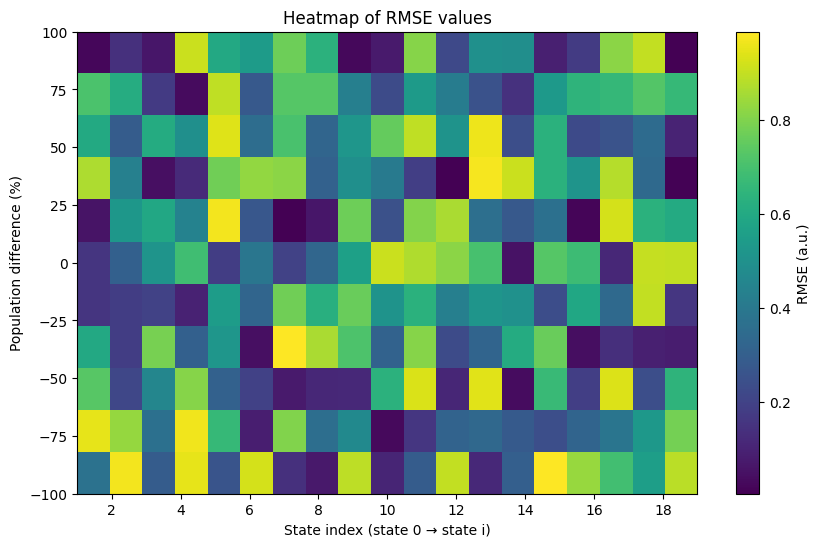

In [ ]:
# # ---------------------------
# # Step 5: Plot heatmap
# # ---------------------------
# plt.figure(figsize=(10,6))
# im = plt.imshow(heatmap, origin='lower', aspect='auto', 
#                 extent=[1,19,population_levels[0], population_levels[-1]], 
#                 cmap='viridis')

# plt.xlabel("State index (state 0 → state i)")
# plt.ylabel("Population difference (%)")
# plt.title("Heatmap of RMSE values")
# plt.colorbar(im, label="RMSE (a.u.)")
# plt.show()


In [49]:
# load models from file
models = torch.load("../hsp90_models.pt").to(device)
# center models (just to be sure)
models = center_models(models)
# Define population weights
w = np.array([0.75, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.25])

# Create weighted ensemble with automatic count calculation
models_ensemble, w_actual, total_models = create_weighted_ensemble(
    models=models,
    w=w,
    verbose=True
)

# save weigthed ensemble - needed for image generation
torch.save(models_ensemble, "models_ensemble.pt")


WEIGHTED ENSEMBLE CREATION (Precision: 0.01)

Input weights (w):
  Non-zero indices: [0, 19]
  Target weights:   ['0.7500', '0.2500']

Optimal integer counts:
  Counts:           [3, 1]
  Total models:     4

Achieved weights (w'):
  Actual weights:   ['0.7500', '0.2500']



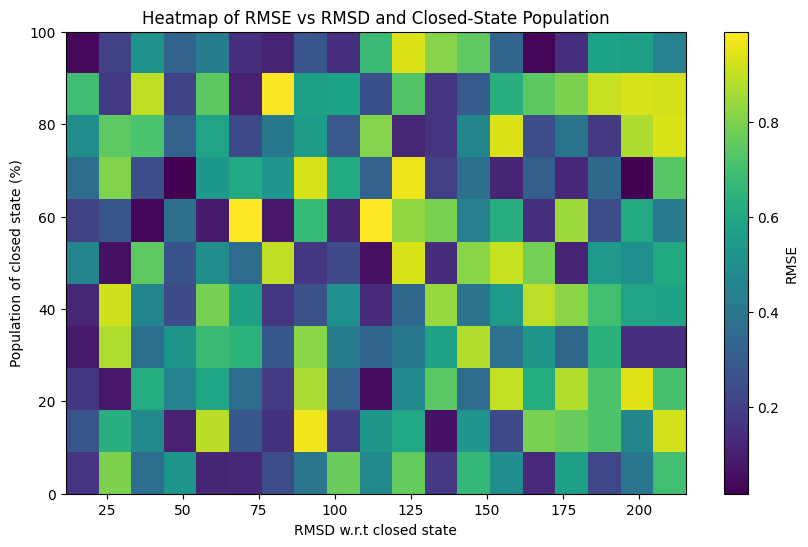

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # ---------------------------
# # Simulate coordinates
# # ---------------------------
# np.random.seed(42)
# n_models = 20
# n_atoms = 10
# coords = np.random.rand(n_models, n_atoms, 3)  # replace with your real coordinates

# # ---------------------------
# # Generate population weights
# # ---------------------------
# def generate_population_weights(n_states=20, population_steps=11):
#     weights_list = []
#     pop_fractions = []
#     state_indices = []
#     fractions = np.linspace(0, 1, population_steps)
#     for i in range(1, n_states):
#         for f in fractions:
#             w = np.zeros(n_states)
#             w[0] = f
#             w[i] = 1 - f
#             weights_list.append(w)
#             pop_fractions.append(f)
#             state_indices.append(i)
#     return np.array(weights_list), np.array(pop_fractions), np.array(state_indices)

# weights, pop_fractions, state_indices = generate_population_weights(n_states=n_models, population_steps=11)

# # ---------------------------
# # Compute RMSD of each model to closed state
# # ---------------------------
# def rmsd(a, b):
#     return np.sqrt(np.mean(np.sum((a - b)**2, axis=1)))

# rmsds_to_closed = np.array([rmsd(models.cpu().numpy()[0], models.cpu().numpy()[i]) for i in range(len(models))])

# # ---------------------------
# # Population difference (%) = fraction of closed state
# # ---------------------------
# pop_diff = np.array([w[0] for w in weights]) * 100  # 0% → 100%

# # ---------------------------
# # X-axis values (RMSD of the other state)
# # ---------------------------
# x_values = rmsds_to_closed[state_indices]  # RMSD of state i relative to closed

# # ---------------------------
# # RMSE values (color)
# # ---------------------------
# rmse_values = np.random.rand(len(weights))  # replace with your actual RMSE metric

# # ---------------------------
# # Prepare heatmap grid
# # ---------------------------
# pop_levels = np.unique(pop_diff)
# rmsd_levels = np.unique(x_values)
# heatmap = np.zeros((len(pop_levels), len(rmsd_levels)))

# for i, pd in enumerate(pop_levels):
#     for j, rmsd_val in enumerate(rmsd_levels):
#         idx = np.where((pop_diff == pd) & (x_values == rmsd_val))[0]
#         if len(idx) > 0:
#             heatmap[i, j] = rmse_values[idx[0]]

# # ---------------------------
# # Plot heatmap
# # ---------------------------
# plt.figure(figsize=(10,6))
# im = plt.imshow(heatmap, origin='lower', aspect='auto',
#                 extent=[rmsd_levels[0], rmsd_levels[-1], pop_levels[0], pop_levels[-1]],
#                 cmap='viridis')

# plt.xlabel("RMSD w.r.t closed state")
# plt.ylabel("Population of closed state (%)")
# plt.title("Heatmap of RMSE vs RMSD and Closed-State Population")
# plt.colorbar(im, label="RMSE")
# plt.show()


We will now simulate the cryo-EM images with our generated models. The simulation is done by the class `CryoEmSimulator` and the simulation is run by the `simulate` function. The class `CryoEmSimulator` takes as input a config file with the simulation parameters. The config file used here is `simulation_parameters.json`.

The following parameters are used in the simulation:
```
{
    "N_PIXELS": 128,
    "PIXEL_SIZE": 1.5,
    "SIGMA": [0.5, 5.0],
    "MODEL_FILE": "models.pt",
    "SHIFT": 0.0,
    "DEFOCUS": [0.5, 2.0],
    "SNR": [0.01, 0.5],
    "AMP": 0.1,
    "B_FACTOR": [1.0, 100.0]
}
```

In [ ]:
# create simulator
simulator = CryoEmSimulator(
    "simulation_parameters.json"
)  # creating simulator with simulation parameters
# generate 100k images
images, parameters = simulator.simulate(
    num_sim=100000, return_parameters=True
)  # simulating images and save parameters
# be sure images are on device
#images = images.to(device)

In [9]:
np.abs

<ufunc 'absolute'>

In [12]:
images, parameters = simulator.simulate(
    num_sim=1000000, return_parameters=True, batch_size=1000
) 

In [13]:
images.shape

torch.Size([1000000, 128, 128])

#### Visualize the simulated images

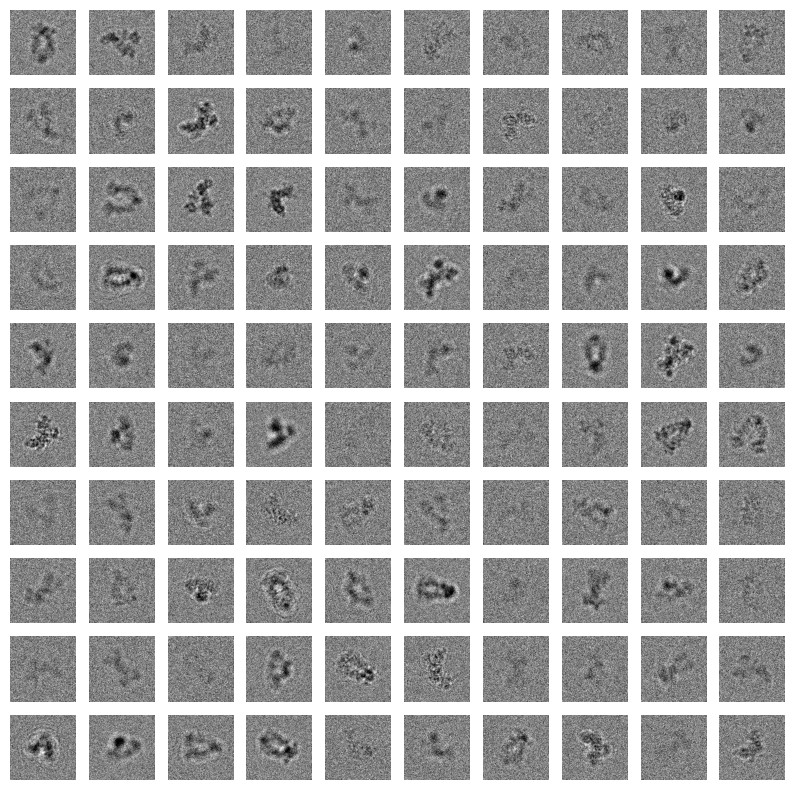

In [51]:
fig, axes = plt.subplots(10, 10, figsize=(10, 10), sharex=True, sharey=True)
for idx, ax in enumerate(axes.flatten()):
    ax.imshow(images[idx], vmin=-3, vmax=3, cmap="gray")
    ax.axis("off")

### Evaluate likelihood matrix

In [21]:
def evaluate_likelihood_pairwise(
    estimator: torch.nn.Module,
    images: torch.Tensor,        # shape: [N_images, H, W]
    models: torch.Tensor,        # not needed, just for interface
    batch_size_pairs: int = 4096,  # Batch size for (image, model) pairs
    device: str = "cuda"
) -> torch.Tensor:
    """
    Evaluate log p(X_i | theta_j) for all pairs efficiently.
    Creates all pairs and processes in large batches.
    
    Returns:
        log_probs: shape [N_images, N_models]
    """
    estimator.eval()
    estimator.to(device)
    images = images.to(device)
    
    N_images = len(images)
    N_models = len(models)
    model_indices = torch.arange(N_models, dtype=torch.float32, device=device)
    
    # Total number of pairs
    total_pairs = N_images * N_models
    
    log_probs = torch.zeros(N_images, N_models, device=device)
    
    with torch.no_grad():
        print(f"Evaluating {total_pairs:,} pairs...")
        
        # Process all pairs in large batches
        for pair_start in tqdm(range(0, total_pairs, batch_size_pairs), desc="Pairs"):
            pair_end = min(pair_start + batch_size_pairs, total_pairs)
            batch_size = pair_end - pair_start
            
            # Compute which (image, model) each pair corresponds to
            pair_indices = torch.arange(pair_start, pair_end, device=device)
            img_idx = pair_indices // N_models  # [batch_size]
            mod_idx = pair_indices % N_models   # [batch_size]
            
            # Gather the corresponding images and model indices
            batch_images = images[img_idx]  # [batch_size, H, W]
            batch_indices = model_indices[mod_idx].unsqueeze(-1)  # [batch_size, 1]
            
            # Single forward pass!
            log_p = estimator(batch_images, batch_indices)  # [batch_size]
            
            # Place results in the correct positions
            log_probs.view(-1)[pair_start:pair_end] = log_p
    
    return log_probs

Before evaluating the likelihood, we reload all the 20 models. No need to center them, only the indexes matter, as the flow has learned the relationship between a cryo-EM image and the model index (from 0 to 19).

In [52]:
# reload models from file
models = torch.load("../hsp90_models.pt")

In [ ]:
# def rmsd(a, b):
#     # a and b are tensors of shape (n_atoms, 3)
#     return torch.sqrt(torch.mean(torch.sum((a - b)**2, dim=1)))


In [ ]:
# models[0]

tensor([[-43.1723, -42.3603, -39.3903,  ...,  58.5457,  59.0447,  60.5567],
        [  1.5186,   4.4486,   2.3916,  ...,   3.9476,   0.2136,  -1.3414],
        [  4.4944,   6.7974,   7.9344,  ...,  -3.3526,  -2.8706,  -6.0186]])

In [102]:
# n_atoms = 10
# rmsds = torch.tensor([rmsd(models[0].transpose(0, 2, 1), models[-1].transpose(0, 2, 1)) for i in range(20)])
# print(rmsds)


In [106]:
test = np.load('test.npy')
test

array([6.34771637e-01, 1.01262205e-01, 8.55405456e-04, 4.42184889e-03,
       1.81515805e-03, 2.41616235e-04, 1.63933256e-01, 7.81926731e-02,
       8.05676694e-04, 1.80351667e-04, 1.12047169e-05, 4.03910004e-05,
       2.23948959e-05, 3.76994123e-05, 3.53470730e-04, 6.36748004e-05,
       8.52720982e-05, 6.15621056e-04, 4.01398766e-05, 1.22503039e-02])

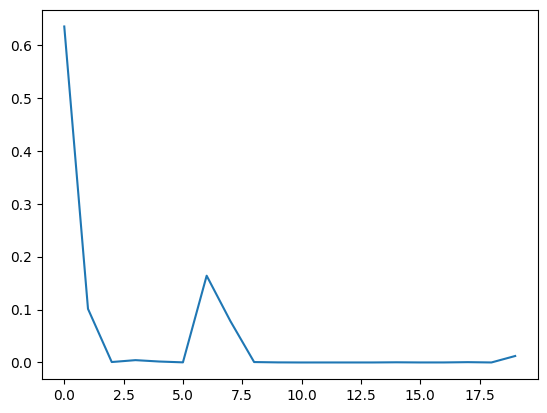

In [107]:
plt.plot(test)

In [53]:
# evaluate likelihood matrix
log_probs_matrix = evaluate_likelihood_pairwise(
    estimator,
    images,
    models,
    batch_size_pairs=10000, # should be ok with 48GB GPU memory
    device=device
)
# transpose to [N_models : N_images]
log_probs_matrix = log_probs_matrix.T

Evaluating 2,000,000 pairs...


Pairs:   0%|          | 0/200 [00:00<?, ?it/s]

### Population inference (BioEM style)

In [14]:
class WeightOptimizer:
    """
    Numerically stable optimizer for:
    L = -sum_i log(sum_j w_j * p_ij) + theta * sum_j w_j * log(w_j / w_j^0)
    """
    
    def __init__(self, log_p, w0=None, theta=0.0, device='cpu'):
        """
        Args:
            log_p: tensor of shape (n_j, n_i) containing log(p_ij)
            w0: prior weights of shape (n_j,), normalized. If None, uses uniform weights.
            theta: regularization parameter (float), default 0.0
            device: 'cpu' or 'cuda'
        """
        self.device = device
        self.log_p = torch.tensor(log_p, dtype=torch.float64, device=device)
        self.n_j, self.n_i = self.log_p.shape
        
        # Initialize w0 as uniform if not provided - used only with theta>0
        if w0 is None:
            self.w0 = torch.ones(self.n_j, dtype=torch.float64, device=device) / self.n_j
            if(theta>0): print(f"Prior weights w0 not specified, using uniform: w0 = 1/{self.n_j}")
        else:
            self.w0 = torch.tensor(w0, dtype=torch.float64, device=device)
        
        self.theta = torch.tensor(theta, dtype=torch.float64, device=device)

    def compute_loss(self, w):
        """
        Compute loss given weights w (must be normalized, sum to 1, non-negative)
        Loss is normalized: average log-likelihood per sample and average KL per weight
        """
        eps = 1e-15
        
        # First term: -(1/n_i) * sum_i log(sum_j w_j * p_ij)
        log_w = torch.log(w + eps)  # shape (n_j,)
        log_terms = log_w.unsqueeze(1) + self.log_p  # shape (n_j, n_i)
        term1 = -torch.logsumexp(log_terms, dim=0).sum() / self.n_i  # average over samples
        
        # Second term: +theta * (1/n_j) * sum_j w_j * log(w_j / w_j^0)
        if self.theta > 0:
            log_w0 = torch.log(self.w0 + eps)
            term2 = self.theta * torch.sum(w * (log_w - log_w0)) / self.n_j  # average over weights
        else:
            term2 = torch.tensor(0.0, dtype=torch.float64, device=self.device)
        
        return term1 + term2
        
    
    def optimize(self, lr=0.1, max_iter=10000, tol=1e-9, verbose=False):
        """
        Optimize weights using PyTorch Adam optimizers
        
        Args:
            lr: learning rate
            max_iter: maximum iterations
            tol: convergence tolerance
            verbose: print progress
        """
        # Use unconstrained parameterization: w = softmax(z)
        # Initialize with random normalized weights
        z_init = torch.randn(self.n_j, dtype=torch.float64, device=self.device)
        z = z_init.clone().detach().requires_grad_(True)
        
        # initialize Adam optimizer
        optimizer = torch.optim.Adam([z], lr=lr)
            
        losses = []
        for iteration in range(max_iter):
             optimizer.zero_grad()
                
             # Convert unconstrained z to normalized weights
             w = torch.softmax(z, dim=0)
                
             loss = self.compute_loss(w)
             loss.backward()
             optimizer.step()
                
             losses.append(loss.item())
                
             if verbose and iteration % 100 == 0:
                  print(f"Iter {iteration}: Loss = {loss.item():.6f}")
                
             # Check convergence
             if iteration > 10 and abs(losses[-1] - losses[-2]) < tol:
                 if verbose:
                     print(f"Converged at iteration {iteration}")
                 break
                    
        # Final weights
        with torch.no_grad():
            w_opt = torch.softmax(z, dim=0)
        
        return w_opt.cpu().numpy(), losses

Now we can finally infer the population of the 20 original models using the usual BioEM/CryoLike formula. We expect only the first and last models to be populated at 75%-25% as designed!

In [54]:
# Initialize optimizer
opt = WeightOptimizer(log_probs_matrix.detach().clone(), device=device)

# Optimize with Adam and find weights that maximize the BioEM posterior
w_opt, _ = opt.optimize()

/tmp/ipykernel_1123549/456877370.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.log_p = torch.tensor(log_p, dtype=torch.float64, device=device)


In [ ]:
def rmse(x_opt, w_actual):
    # Convert to numpy if needed
    if torch.is_tensor(x_opt):
        x_opt = x_opt.detach().cpu().numpy()
    if torch.is_tensor(w_actual):
        w_actual = w_actual.detach().cpu().numpy()
    
    # Calculate RMSE
    rmse = np.sqrt(np.mean((x_opt - w_actual)**2))
    return rmse 

In [25]:
def plot_weights_comparison(x_opt, w_actual):
    """
    Plot comparison between optimized and actual weights with RMSE.
    
    Parameters:
        x_opt: numpy.array or torch.Tensor shape (n,) - optimized weights
        w_actual: numpy.array or torch.Tensor shape (n,) - actual/true weights
        save_path: optional path to save the figure
    
    Returns:
        rmse: float - Root Mean Squared Error between x_opt and w_actual
    """
    # Convert to numpy if needed
    if torch.is_tensor(x_opt):
        x_opt = x_opt.detach().cpu().numpy()
    if torch.is_tensor(w_actual):
        w_actual = w_actual.detach().cpu().numpy()
    
    # Calculate RMSE
    rmse = np.sqrt(np.mean((x_opt - w_actual)**2))
    
    # Create grouped bar plot
    fig, ax = plt.subplots(figsize=(10, 4))
    
    n_mod = len(x_opt)
    model_indexes = np.arange(1, n_mod + 1)
    bar_width = 0.35
    x_pos = np.arange(n_mod)
    
    # Plot both bars
    bars1 = ax.bar(x_pos - bar_width/2, x_opt, bar_width, 
                   label='CryoSB-Like weights', color='#3498db', 
                   alpha=0.8, edgecolor='black', linewidth=1.2)
    bars2 = ax.bar(x_pos + bar_width/2, w_actual, bar_width, 
                   label='True weights', color='#2ecc71', 
                   alpha=0.8, edgecolor='black', linewidth=1.2)
    
    # Labels and styling
    ax.set_xlabel('Model Index', fontsize=12, weight='bold')
    ax.set_ylabel('Weight', fontsize=12, weight='bold')
    ax.set_title(f'Weights Comparison - RMSE = {rmse:.6f}', 
                 fontsize=14, weight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(model_indexes)
    ax.set_xlim(-0.5, n_mod - 0.5)
    ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    
    plt.show()
    
    return rmse

Now we plot the inferred weights along with the ground truth (and the RMSE)

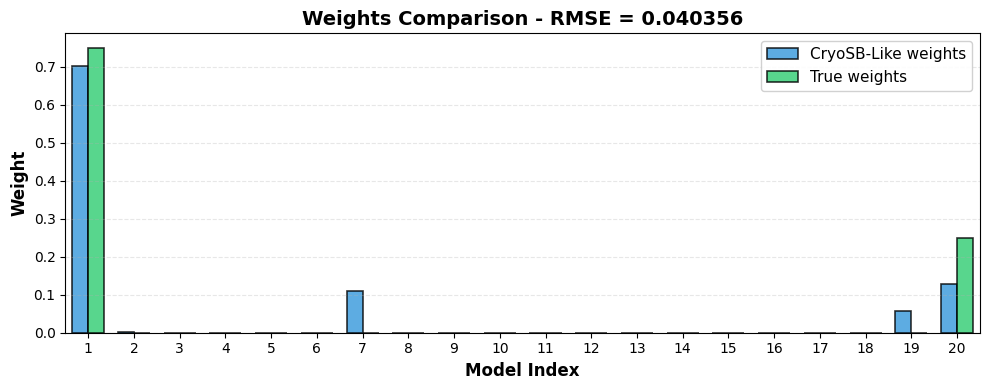

In [55]:
rmse = plot_weights_comparison(w_opt, w_actual)

In [29]:
rmse

np.float64(0.17165217926849774)

### Population inference (BME style)

In [ ]:
def run_theta_analysis(log_probs_matrix, x_true, w0=None, theta_max=1000.0, n_points=50, 
                       verbose=False, device='cpu'):
    """
    Run optimization over a grid of theta values and compute RMSE.
    
    Parameters:
        log_probs_matrix: torch.Tensor shape (n, m) - log likelihoods
        x0_prior: torch.Tensor or numpy.array shape (n,) - prior weights (optional, default: uniform)
        theta_max: maximum theta value
        n_points: number of theta values to test
        verbose: whether to print progress for each optimization
    
    Returns:
        theta_values: array of theta values
        weights_dict: dictionary mapping theta -> optimized weights
        rmse_values: array of RMSE values
    """
    
    # Create theta grid (linearly-spaced)
    theta_values = np.linspace(0.0, theta_max, n_points, endpoint=True)
    
    weights_dict = {}
    rmse_values = []
    losses_values = []
    
    print(f"Running optimization for {len(theta_values)} theta values...")
    
    for i, theta in enumerate(theta_values):
        if (i % 5 == 0):
            print(f"Progress: {i}/{len(theta_values)} - theta = {theta:.4f}")

        # Initialize optimizer
        opt = WeightOptimizer(log_probs_matrix, w0=w0, theta=theta, device=device)
        x_opt,l = opt.optimize()
        
        # Store weights in dictionary
        weights_dict[theta] = x_opt
        # and final loss
        losses_values.append(l[-1])
        
        # Compute RMSE with respect to prior weights
        rmse = np.sqrt(np.mean((x_opt - x_true)**2))
        rmse_values.append(rmse)
    
    rmse_values = np.array(rmse_values)
    losses_values = np.array(losses_values)
    
    print("Done!")
    return theta_values, weights_dict, rmse_values, losses_values

Now we infer the population of the 20 original models using the BioEM/CryoLike formula with an added regularization term - BME style. We do this for a range of theta from 0 to theta_max. We use as prior weights a uniform distribution.

In [ ]:
# Perform optimization for a range of thetas
# we don't provide prior weights w0 = uniform weights
theta_values, weights_dict, rmse_values, losses_values = run_theta_analysis(
    log_probs_matrix,
    w_actual,
    w0=None,
    theta_max=100.0,
    n_points=50,
    device=device
)

In [ ]:
def plot_rmse_vs_theta(theta_values, rmse_values):
    """
    Plot RMSE as a function of theta.
    
    Parameters:
        theta_values: array of theta values
        rmse_values: array of RMSE values
    """
    fig, ax = plt.subplots(1, 1, figsize=(7, 5))
    
    # Linear scale
    ax.plot(theta_values, rmse_values, 'b-', linewidth=2, marker='o', markersize=4)
    ax.set_xlabel('θ (Regularization Strength)', fontsize=12)
    ax.set_ylabel('RMSE', fontsize=12)
    ax.set_title('RMSE vs θ', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print some statistics
    min_idx = np.argmin(rmse_values)
    print(f"\nMinimum RMSE: {rmse_values[min_idx]:.6f} at θ = {theta_values[min_idx]:.4f}")
    print(f"RMSE at θ=0: {rmse_values[0]:.6f}")

In [ ]:
# Plot results
plot_rmse_vs_theta(theta_values, rmse_values)
# Visualize set of weights for a given theta value
# Let's start with theta=0.0
rmse = plot_weights_comparison(weights_dict[0.0], w_actual)
# And let's plot also theta=theta_max (should be uniform-ish, i.e. the prior)
rmse = plot_weights_comparison(weights_dict[100.0], w_actual)